<a href="https://colab.research.google.com/github/rahafabumwise/instacart-ml-project/blob/main/notebooks/step_by_step_SVM_classification_tsk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os

Mounted at /content/drive


In [ ]:
import pandas as pd
clf_data = pd.read_parquet("/content/drive/MyDrive/instacart_project/data/classification/clf_df.parquet")

In [ ]:
clf_data.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
0,202279,33120,5,0.0,0.800000,8,11.25,0.477778,21.862499,30.0,19400,0.708454,6.816959,18.204227,1,1,1
1,202279,28985,5,54.0,0.800000,8,11.25,0.477778,21.862499,30.0,67449,0.694465,7.501683,15.959421,0,0,0
2,202279,9327,1,123.0,0.000000,8,11.25,0.477778,21.862499,30.0,6299,0.157962,9.943166,14.909350,0,0,0
3,202279,45918,5,30.0,0.800000,8,11.25,0.477778,21.862499,30.0,744,0.272849,8.444893,17.795698,0,0,0
4,202279,30035,3,30.0,0.666667,8,11.25,0.477778,21.862499,30.0,569,0.507909,8.481546,19.773287,0,0,0


#Split data

In [ ]:
user_label = clf_data.groupby("user_id")["reorder"].max().astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

train_users, test_users = train_test_split(
    users,
    test_size=0.2,
    random_state=42,
    stratify=y_user
)

In [ ]:
cl_train_df = clf_data[clf_data["user_id"].isin(train_users)].copy()
cl_test_df  = clf_data[clf_data["user_id"].isin(test_users)].copy()

In [ ]:
# 1) No overlap in users
assert set(cl_train_df["user_id"]).isdisjoint(set(cl_test_df["user_id"]))

# 2) Distribution check (row-level)
print("Row reorder rate - train:", cl_train_df["reorder"].mean())
print("Row reorder rate - test :", cl_test_df["reorder"].mean())

# 3) Distribution check (user-level)
print("User reorder rate - train:", user_label.loc[train_users].mean())
print("User reorder rate - test :", user_label.loc[test_users].mean())

Row reorder rate - train: 0.06228055421132008
Row reorder rate - test : 0.062279545787892056
User reorder rate - train: 0.5945734601465748
User reorder rate - test : 0.594588041317104


In [ ]:
user_label = cl_train_df.groupby("user_id")["reorder"].max().astype(int)
from sklearn.model_selection import train_test_split

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

sample, _= train_test_split(
    users,
    train_size=0.1,
    random_state=42,
    stratify=y_user
)

In [ ]:
sample_df = cl_train_df[cl_train_df["user_id"].isin(sample)].copy()

In [ ]:
sample_df.shape

(1071950, 17)

In [ ]:
sample_df.head()

,user_id,product_id,prior_purchase_count_uxp,days_since_last,reorder_prob_userxprod,user_total_orders,user_average_basket,user_reorder_ratio,user_mean_days_between_order,user_last_interorder_gap,product_total_purchase,product_reorder_ratio,product_avg_cart_pos,product_pop_overtime,reorder,streak,last_order_contains_product
216,193635,40078,1,48.0,0.0,26,6.730769,0.52,7.362069,8.0,3573,0.492583,10.029107,17.527569,0,0,0
217,193635,9065,2,21.0,0.5,26,6.730769,0.52,7.362069,8.0,1944,0.448560,8.731996,14.029321,0,0,0
218,193635,46175,2,21.0,0.5,26,6.730769,0.52,7.362069,8.0,5928,0.447031,8.429150,12.042004,0,0,0
342,39630,20915,1,0.0,0.0,14,7.142857,0.19,4.258065,4.0,743,0.627187,7.717362,13.932705,0,1,1
343,39630,21949,1,0.0,0.0,14,7.142857,0.19,4.258065,4.0,1531,0.602874,10.124755,19.412149,0,1,1


In [ ]:
print("sample_df shape:", sample_df.shape)
print("unique users in sample_df:", sample_df["user_id"].nunique())
print("expected users in sample:", len(sample))

# sanity: every sampled user exists in sample_df
missing = set(sample) - set(sample_df["user_id"].unique())
print("missing sampled users:", len(missing))

sample_df shape: (1071950, 17)
unique users in sample_df: 16496
expected users in sample: 16496
missing sampled users: 0


In [ ]:
print("sample reorder ratio:", sample_df["reorder"].mean())

sample reorder ratio: 0.061565371519193994


#Linear SVM

##baseline

In [ ]:
TARGET = "reorder"
GROUP  = "user_id"

y = sample_df[TARGET].astype(int)
groups = sample_df[GROUP]

X = sample_df.drop(["user_id", "product_id", TARGET], axis=1)

print("X:", X.shape, "y:", y.shape, "groups:", groups.nunique())
print("positive rate:", y.mean())

X: (1071950, 14) y: (1071950,) groups: 16496
positive rate: 0.061565371519193994


In [ ]:
right_tailed_features = ["prior_purchase_count_uxp", "days_since_last", "product_total_purchase", "streak"]
other_features = ["reorder_prob_userxprod","user_total_orders","user_average_basket", "user_reorder_ratio", "user_mean_days_between_order","user_last_interorder_gap","product_reorder_ratio","product_avg_cart_pos" ,"product_pop_overtime"]
binary_features = ["last_order_contains_product"]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
import numpy as np

log_and_scale = Pipeline([
    ("log", FunctionTransformer(np.log1p, validate=False)),
    ("scaler", StandardScaler())
])

scale_only = Pipeline([
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("log_features", log_and_scale, right_tailed_features),
    ("normal_features", scale_only, other_features),
    ("binary_features", "passthrough", binary_features)
])

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline

pipe_svm_lin_baseline = Pipeline([
    ("preprocess", ColumnTransformer(
        [
            ("log_features", log_and_scale, right_tailed_features),
            ("normal_features", scale_only, other_features),
            ("binary_features", "passthrough", binary_features),
        ],
        sparse_threshold=0.0,
    )),
    ("clf", SGDClassifier(
        loss="hinge",
        random_state=42,
        class_weight="balanced"
    ))
])

We implemented a linear Support Vector Machine. Due to the scale of the dataset, we used SGDClassifier with hinge loss, which optimizes the same linear SVM objective as LinearSVC, but scales better to large datasets. This choice affects the optimization method, not the underlying model

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

def get_oof_scores(pipe, X, y, groups, n_splits=3):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y), dtype=float)

    for tr_idx, va_idx in gkf.split(X, y, groups):
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = pipe.decision_function(X.iloc[va_idx])

    return oof


In [ ]:
oof_scores = get_oof_scores(
    pipe_svm_lin_baseline,
    X, y, groups,
    n_splits=3
)

In [ ]:
print("ROC-AUC:", roc_auc_score(y, oof_scores))
print("PR-AUC (AP):", average_precision_score(y, oof_scores))


ROC-AUC: 0.8070163734021407
PR-AUC (AP): 0.23134017563732606


##Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import make_scorer, average_precision_score

gkf = GroupKFold(n_splits=3)

param_grid = {
    "clf__penalty": ["l2", "l1"],
    "clf__class_weight": ["balanced", None],
    "clf__alpha": [1e-6, 1e-5, 1e-4, 1e-3],
}

grid = GridSearchCV(
    estimator=pipe_svm_lin_baseline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=gkf,
    n_jobs=-1,
    verbose=2
)

grid.fit(X, y, groups=groups)

print("Best params:", grid.best_params_)
print("Best PR-AUC (AP):", grid.best_score_)


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best params: {'clf__alpha': 1e-05, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}
Best PR-AUC (AP): 0.23379379625029997


In [ ]:
best_svm_lin = grid.best_estimator_
print(best_svm_lin)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(sparse_threshold=0.0,
                                   transformers=[('log_features',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['prior_purchase_count_uxp',
                                                   'days_since_last',
                                                   'product_total_purchase',
                                                   'streak']),
                                                 ('normal_features',
                                                  Pipeline(steps=[('scaler',
                                                             

We tuned the Linear SVM (SGD hinge) using GridSearchCV with 3-fold GroupKFold (grouped by user_id) and optimized Average Precision (PR-AUC). The best configuration was penalty=L1, alpha=1e-5, class_weight=balanced, achieving PR-AUC ≈ 0.2338 on grouped CV

##threshold

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold

oof_scores = get_oof_scores(
    best_svm_lin,
    X, y, groups,
    n_splits=3
)


In [ ]:
from sklearn.metrics import f1_score

thresholds = np.percentile(oof_scores, np.linspace(5, 95, 91))  # 5%..95% (fast)
best_thr = None
best_f1 = -1

for t in thresholds:
    preds = (oof_scores >= t).astype(int)
    f1 = f1_score(y, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = t

print("Best threshold:", best_thr)
print("Best OOF F1:", best_f1)


Best threshold: 1.024902020147267
Best OOF F1: 0.3138864830532941


Unlike logistic regression and tree-based models, linear SVM does not naturally output class probabilities. Instead, it produces decision scores corresponding to the signed distance from the separating hyperplane. These scores are unbounded and can take values outside the [0, 1] range. Classification therefore depends on selecting a threshold on the decision scores rather than on probabilities. In this work, the threshold was chosen to maximize the F1-score using out-of-fold predictions, which is particularly important under strong class imbalance.

##final model

In [ ]:
TARGET = "reorder"
X_train = cl_train_df.drop(["user_id", "product_id", TARGET], axis=1)
y_train = cl_train_df[TARGET].astype(int)
X_test = cl_test_df.drop(["user_id", "product_id", TARGET], axis=1)
y_test = cl_test_df[TARGET].astype(int)

In [ ]:
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score

best_svm_lin = grid.best_estimator_
best_svm_lin.fit(X_train, y_train)

test_scores = best_svm_lin.decision_function(X_test)

y_pred = (test_scores >= best_thr).astype(int)

print("Test F1 (best_thr):", f1_score(y_test, y_pred))
print("Test ROC-AUC:", roc_auc_score(y_test, test_scores))
print("Test PR-AUC (AP):", average_precision_score(y_test, test_scores))


Test F1 (best_thr): 0.3149670425969672
Test ROC-AUC: 0.8100975340445498
Test PR-AUC (AP): 0.22696085514501346


After selecting the optimal hyperparameters and decision-score threshold using grouped cross-validation on the sampled training data, the Linear SVM was refit on the full training set and evaluated on the held-out test users. On the test set, the model achieved ROC-AUC = 0.810, PR-AUC(AP) = 0.227, and F1 = 0.315. The slight decrease in PR-AUC compared to cross-validated results is expected when moving from validation folds to a fully unseen test split and reflects normal generalization behavior rather than overfitting or pipeline issues

##plots

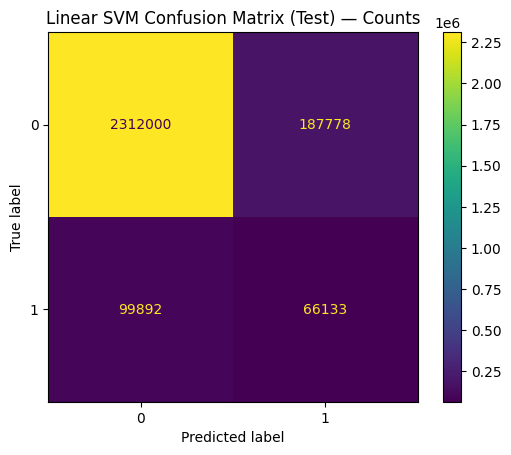

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(values_format="d")
plt.title("Linear SVM Confusion Matrix (Test) — Counts")
plt.show()



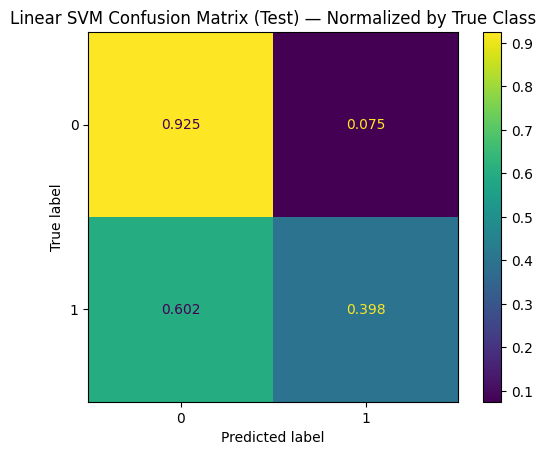

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=[0, 1])
disp.plot(values_format=".3f")
plt.title("Linear SVM Confusion Matrix (Test) — Normalized by True Class")
plt.show()


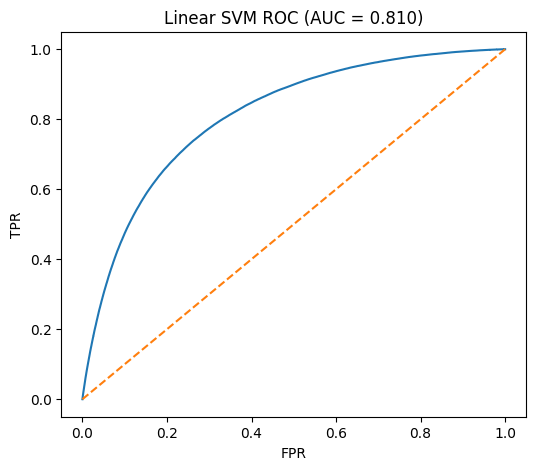

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, test_scores)
auc = roc_auc_score(y_test, test_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title(f"Linear SVM ROC (AUC = {auc:.3f})")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()


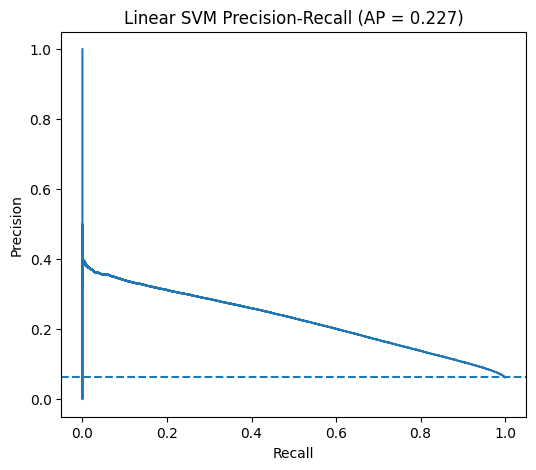

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

prec, rec, _ = precision_recall_curve(y_test, test_scores)
ap = average_precision_score(y_test, test_scores)

plt.figure(figsize=(6,5))
plt.plot(rec, prec)
plt.axhline(y_test.mean(), linestyle="--")
plt.title(f"Linear SVM Precision-Recall (AP = {ap:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


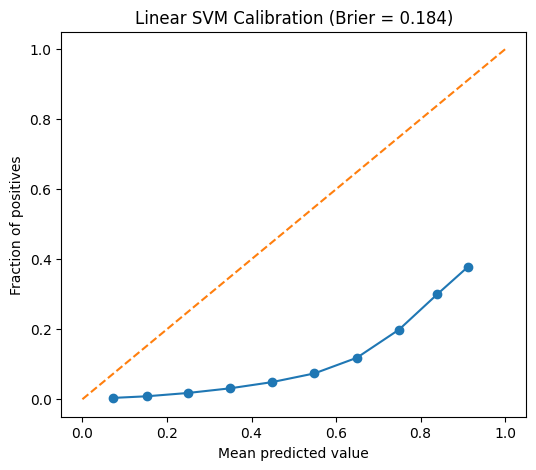

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np

probs = 1 / (1 + np.exp(-test_scores))   # sigmoid(scores)

frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="uniform")
brier = brier_score_loss(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, marker="o")
plt.plot([0,1],[0,1], linestyle="--")
plt.title(f"Linear SVM Calibration (Brier = {brier:.3f})")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.show()


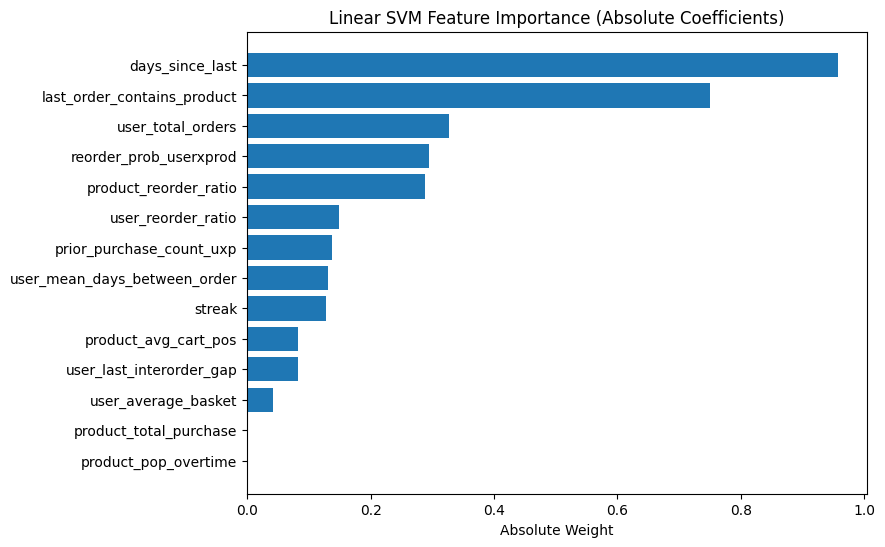

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# coefficients = weights for Linear SVM
weights = best_svm_lin.named_steps["clf"].coef_.ravel()

feature_names = right_tailed_features + other_features + binary_features

imp_df = pd.DataFrame({
    "feature": feature_names,
    "weight": weights,
    "importance": np.abs(weights)
}).sort_values("importance", ascending=False)

# plot top 15
top_k = 15
plt.figure(figsize=(8,6))
plt.barh(
    imp_df.head(top_k)["feature"],
    imp_df.head(top_k)["importance"]
)
plt.gca().invert_yaxis()
plt.title("Linear SVM Feature Importance (Absolute Coefficients)")
plt.xlabel("Absolute Weight")
plt.show()


#RBF SVM

In [ ]:
from sklearn.model_selection import train_test_split
TARGET = "reorder"
user_label = cl_train_df.groupby("user_id")[TARGET].max().astype(int)

users = user_label.index.to_numpy()
y_user = user_label.to_numpy()

small_users, _ = train_test_split(
    users,
    train_size=0.0125,
    random_state=42,
    stratify=y_user
)

rbf_df = cl_train_df[cl_train_df["user_id"].isin(small_users)].copy()

print("rbf_df shape:", rbf_df.shape)
print("unique users:", rbf_df["user_id"].nunique())
print("positive rate:", rbf_df[TARGET].mean())


rbf_df shape: (135913, 17)
unique users: 2062
positive rate: 0.060170844584403256


In [ ]:
GROUP = "user_id"

y_rbf = rbf_df[TARGET].astype(int)
groups_rbf = rbf_df[GROUP]

X_rbf = rbf_df.drop(["user_id", "product_id", TARGET], axis=1)

print("X:", X_rbf.shape, "y:", y_rbf.shape, "unique groups:", groups_rbf.nunique())


X: (135913, 14) y: (135913,) unique groups: 2062


##baseline

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

pipe_svm_rbf_baseline = Pipeline([
    ("preprocess", preprocess),
    ("clf", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    ))
])


In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, average_precision_score

gkf = GroupKFold(n_splits=3)

oof_scores_rbf = np.zeros(len(y_rbf), dtype=float)

for tr_idx, va_idx in gkf.split(X_rbf, y_rbf, groups_rbf):
    pipe_svm_rbf_baseline.fit(X_rbf.iloc[tr_idx], y_rbf.iloc[tr_idx])
    oof_scores_rbf[va_idx] = pipe_svm_rbf_baseline.decision_function(X_rbf.iloc[va_idx])

print("RBF SVM OOF ROC-AUC:", roc_auc_score(y_rbf, oof_scores_rbf))
print("RBF SVM OOF PR-AUC (AP):", average_precision_score(y_rbf, oof_scores_rbf))


RBF SVM OOF ROC-AUC: 0.7772798491098406
RBF SVM OOF PR-AUC (AP): 0.16804102724810885


A baseline RBF (kernel) SVM was evaluated on a strongly subsampled, user-level split of the training data due to known scalability limitations of kernel-based methods. Even with aggressive subsampling (≈1–2% of the data), training and validation required substantial runtime (≈25 minutes), while achieving lower ROC-AUC and PR-AUC compared to the Linear SVM. Given the high computational cost and inferior performance at the baseline level, further hyperparameter tuning was not pursued, as it would significantly increase runtime without a reasonable expectation of outperforming simpler and more scalable models.

#Support Vector Machines (SVM) — Overall Conclusions

Support Vector Machines were evaluated as part of the classification task using both linear and kernel-based (RBF) variants. Due to the large scale of the dataset and the strong class imbalance, all experiments were conducted using leakage-safe, user-based splits with GroupKFold to ensure that no user information leaked across training and validation folds.

Linear SVM

A Linear SVM was implemented using SGDClassifier with hinge loss, which optimizes the same objective as a traditional linear SVM but scales efficiently to large datasets. Hyperparameters were tuned using GridSearchCV, focusing on regularization type (L1 vs. L2), regularization strength (alpha), and optional class weighting, with Average Precision (PR-AUC) as the optimization metric.

Since linear SVMs output decision scores rather than probabilities, an operating threshold was selected based on out-of-fold predictions to maximize the F1-score, which is more appropriate under strong class imbalance. The optimized threshold was then fixed and applied during test-time evaluation.

On the held-out test set, the tuned Linear SVM achieved strong and stable performance (ROC-AUC ≈ 0.81, PR-AUC ≈ 0.23, F1 ≈ 0.315). Feature importance analysis based on the absolute values of model coefficients showed that recency-based user–product interaction features (e.g., days since last purchase, last-order indicators) were the most influential, aligning well with domain intuition. Overall, the Linear SVM proved to be computationally efficient, interpretable, and competitive, making it a solid linear baseline for this task.

Kernel (RBF) SVM

A kernel-based SVM with an RBF kernel was also evaluated. Due to the well-known quadratic to cubic scaling of kernel SVMs, experiments were limited to a strongly subsampled version of the training data. Even under aggressive subsampling, training and validation required substantial runtime (on the order of tens of minutes), while achieving lower ROC-AUC and PR-AUC compared to the Linear SVM.

Given the combination of inferior performance, high computational cost, and limited scalability, further hyperparameter tuning of the RBF SVM was not pursued. This decision reflects a practical modeling choice: grid search is intended to refine competitive models, not to rescue models that are already dominated at the baseline level.

Final SVM Takeaways

Overall, the experiments indicate that the problem is largely linearly separable given the engineered features, particularly and that linear decision boundaries are sufficient to capture the dominant patterns in user reorder behavior. While kernel SVMs are theoretically more expressive, they were not suitable for this dataset due to scalability constraints and did not provide empirical benefits over the linear variant. Consequently, the Linear SVM was retained as the representative SVM model, while the RBF SVM was documented as a controlled experiment illustrating the trade-off between model complexity and computational feasibility.